In [1]:
# import os

# os.environ["TQDM_DISABLE"] = "True"
# os.environ["TQDM_MININTERVAL"] = "10"

# TODO: install rtree

In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
# import tree_comparison.tree_compare as tc
# from joblib import Memory
from itertools import combinations
from glob import glob
import pandas as pd
import numpy as np
# from utils import *
import utils as u

In [35]:
morphos = {}
records = []

files = glob("/data/*/Complete_annotated/*.json")[:]
for file in files:
    try:
        morphos[file], soma = u.load_morphology_and_soma(file)
        soma["file"] = file
        records.append(soma)
    except KeyError as e:
        pass

In [5]:
import neuron_morphology.vis.morphovis as mv 
import matplotlib.pyplot as plt
%matplotlib inline

# fig, ax = plt.subplots(1,2)
# mv.plot_morphology_xy(morphos[files[0]], ax=ax[0])
# mv.plot_morphology_zy(morphos[files[0]], ax=ax[1])

## Soma info

In [37]:
soma_df = pd.concat(records)
soma_df["zz"] = np.minimum(soma_df["z"], 11400-soma_df["z"])
soma_df.head()

,x,y,z,allenId,sampleNumber,parentNumber,type,file,zz
0,9697.7129,4986.8796,7189.7776,146,0,-1,1,/data/648434_12_5_24/Complete_annotated/N012-6...,4210.2224
0,10547.6826,4832.4666,4863.8392,771,0,-1,1,/data/648434_12_5_24/Complete_annotated/N022-6...,4863.8392
0,9805.1909,5907.0996,4330.8163,658,0,-1,1,/data/648434_12_5_24/Complete_annotated/N026-6...,4330.8163
0,10728.7251,4441.3044,4679.5984,771,0,-1,1,/data/648434_12_5_24/Complete_annotated/N023-6...,4679.5984
0,10184.9323,4583.9386,4759.3966,771,0,-1,1,/data/648434_12_5_24/Complete_annotated/N020-6...,4759.3966


In [38]:
len(soma_df)

114

In [39]:

soma_df["subject"] = [x.split("/")[2].split("_")[0] for x in soma_df["file"]]
soma_df = soma_df.query("x>10000 and y<5500")
soma_df.shape

(104, 10)

(10011.240725, 11043.651775, 3690.5139249999997, 5293.450975)

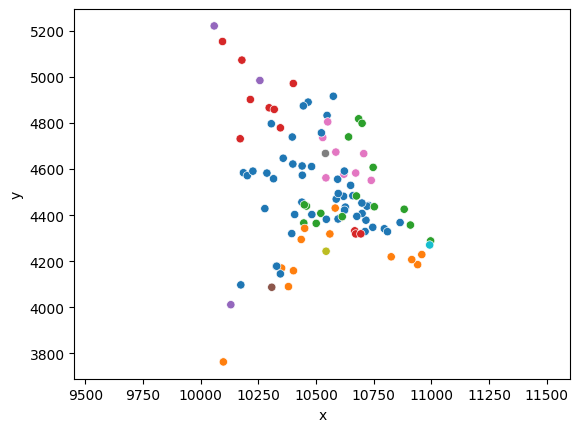

In [40]:
import seaborn as sns
sns.scatterplot(soma_df, x="x", y="y", hue="allenId", palette="tab10", legend=False)
plt.axis('equal')

(10011.240725, 11043.651775, 4497.22813, 7040.88947)

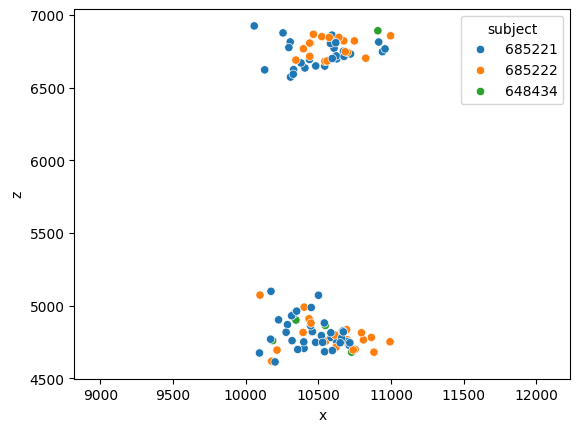

In [41]:
sns.scatterplot(soma_df.sample(frac=1), x="x", y="z", hue="subject", palette="tab10", legend=True)
plt.axis('equal')

## soma sizes

In [51]:
soma_size = pd.read_csv("/data/LC_cells_radii.csv")
# parse string to list

soma_size["radius"] = soma_size["radius"].str.replace("[", "").str.replace("]", "").str.strip().str.split(" ")
# convert to float
soma_size["radius"] = soma_size["radius"].apply(lambda x: [float(i) for i in x if i != ""])
# move column of lists to separate columns
soma_size = soma_size.assign(
    r0=soma_size["radius"].apply(lambda x: x[0]), 
    r1=soma_size["radius"].apply(lambda x: x[1]), 
    r2=soma_size["radius"].apply(lambda x: x[2])
).drop(columns=["radius"])
soma_size = soma_size.query("count==1 and r2<200")
soma_size.shape


/tmp/ipykernel_26772/3979018801.py:4: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  soma_size["radius"] = soma_size["radius"].str.replace("[", "").str.replace("]", "").str.strip().str.split(" ")


(104, 8)

In [52]:
soma_df["id"] = soma_df["file"].apply(lambda x: x.split("/")[-1][:11])
merged = soma_df.merge(soma_size, on="id", how="left")
merged.head()

,x,y,z,allenId,sampleNumber,parentNumber,type,file,zz,subject,id,count,soma,volume,rsquared,r0,r1,r2
0,10547.6826,4832.4666,4863.8392,771,0,-1,1,/data/648434_12_5_24/Complete_annotated/N022-6...,4863.8392,648434,N022-648434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10728.7251,4441.3044,4679.5984,771,0,-1,1,/data/648434_12_5_24/Complete_annotated/N023-6...,4679.5984,648434,N023-648434,1.0,"[32289.0,10717.0,11379.0]",327720.0055,0.789466,31.682105,34.900041,70.757809
2,10184.9323,4583.9386,4759.3966,771,0,-1,1,/data/648434_12_5_24/Complete_annotated/N020-6...,4759.3966,648434,N020-648434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10909.1352,4357.0134,6891.9433,202,0,-1,1,/data/648434_12_5_24/Complete_annotated/N011-6...,4508.0567,648434,N011-648434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10345.3048,4778.6333,4901.0922,1093,0,-1,1,/data/648434_12_5_24/Complete_annotated/N025-6...,4901.0922,648434,N025-648434,1.0,"[31447.0,11515.0,11629.0]",301477.9613,0.935803,28.502765,33.116045,76.250290


(10011.240725, 11043.651775, 4502.418385, 7040.642315)

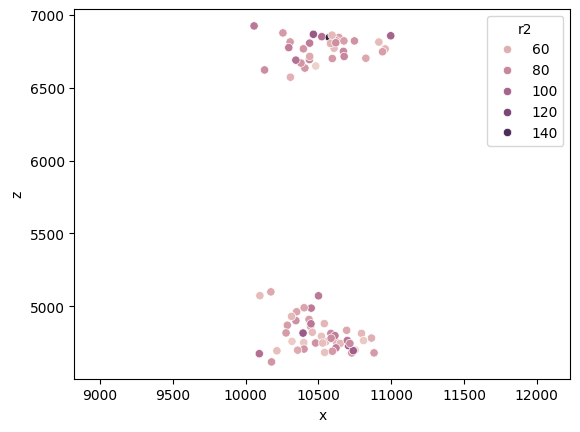

In [53]:
sns.scatterplot(merged.sample(frac=1), x="x", y="z", hue="r2", legend=True)
plt.axis('equal')

(10011.240725, 11043.651775, 4502.418385, 7040.642315)

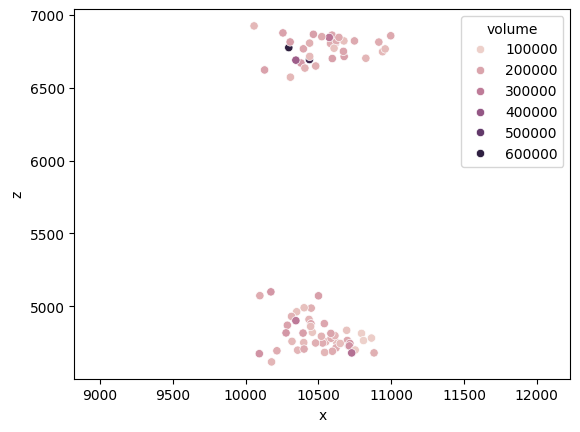

In [54]:
sns.scatterplot(merged.sample(frac=1), x="x", y="z", hue="volume", legend=True)
plt.axis('equal')

# Length-based

## distances

In [17]:
compare.func(pairs[0], "length")

100%|██████████| 28/28 [00:00<00:00, 1014.18it/s]


{'file1': '/data/648434_12_5_24/Complete_annotated/N022-648434-PG.json',
 'file2': '/data/648434_12_5_24/Complete_annotated/N023-648434-HD.json',
 'distance': 3913.1817,
 'norm_distance': 0.5668}

In [21]:
from importlib import reload
reload(u)

<module 'utils' from '/root/capsule/code/utils.py'>

In [22]:
from joblib import Parallel, delayed

# files = glob("/data/*/Complete_annotated/*.json")[:]
pairs = list(combinations(soma_df["file"], 2))
records = []


# with Pool(processes=16) as pool:
#     results = list(
#         tqdm(pool.imap(compare, pairs), total=len(pairs), desc="Comparing trees", unit="pair")
#     )
func = lambda x: u.compare(x, "length")
print(f"Number of pairs: {len(pairs)}")
generator = Parallel(n_jobs=16, return_as="generator", verbose=10)(delayed(func)(pair) for pair in pairs)
# results = list(tqdm(generator, desc="Comparing trees", unit="pair", total=len(pairs)))
results = list(generator)
    


Number of pairs: 5778


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


Error comparing /data/648434_12_5_24/Complete_annotated/N022-648434-PG.json and /data/648434_12_5_24/Complete_annotated/N024-648434-SS.json: 'dendrite'


100%|██████████| 28/28 [00:00<00:00, 45.50it/s]
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:   33.3s
 71%|███████▏  | 20/28 [00:00<00:00, 26.17it/s] 


Error comparing /data/648434_12_5_24/Complete_annotated/N022-648434-PG.json and /data/685221_12_5_24/Complete_annotated/N064-68221-JN.json: 'dendrite'


...

 96%|█████████▌| 69/72 [00:04<00:00, 12.84it/s]

Error comparing /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json and /data/685222_2_17_25_unrefined/Complete_annotated/N007-685222-BP.json: 'dendrite'
Error comparing /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json and /data/685222_2_17_25_unrefined/Complete_annotated/N032-685222-AK.json: 'dendrite'
Error comparing /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json and /data/685222_2_17_25_unrefined/Complete_annotated/N028-685222-VM.json: 'dendrite'
Error comparing /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json and /data/685222_2_17_25_unrefined/Complete_annotated/N006-685222-DS.json: 'dendrite'
Error comparing /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json and /data/685222_2_17_25_unrefined/Complete_annotated/N019-685222-HS.json: 'dendrite'
Error comparing /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json and /data/685222_2_17_25_unrefined/Complete_annotated/N012-685222-BP.json: 'dendrite'
Error comparing /data/

 31%|███       | 22/72 [00:00<00:02, 21.99it/s]

Error comparing /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json and /data/685222_2_17_25_unrefined/Complete_annotated/N001-685222-SA.json: 'dendrite'
Error comparing /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json and /data/685222_2_17_25_unrefined/Complete_annotated/N023-685222-SP.json: 'dendrite'
Error comparing /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json and /data/685222_2_17_25_unrefined/Complete_annotated/N036-685222-YV.json: 'dendrite'
Error comparing /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json and /data/685222_2_17_25_unrefined/Complete_annotated/N027-685222-DS.json: 'dendrite'
Error comparing /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json and /data/685222_2_17_25_unrefined/Complete_annotated/N016-685222-YP.json: 'dendrite'
Error comparing /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json and /data/685222_2_17_25_unrefined/Complete_annotated/N009-685222-SP.json: 'dendrite'
Error comparing /data/

100%|██████████| 18/18 [00:00<00:00, 45.87it/s]
[Parallel(n_jobs=16)]: Done 4968 tasks      | elapsed: 36.3min
100%|██████████| 19/19 [00:00<00:00, 68.98it/s]
[Parallel(n_jobs=16)]: Done 5273 tasks      | elapsed: 37.8min
100%|██████████| 23/23 [00:00<00:00, 118.61it/s]

100%|██████████| 16/16 [00:01<00:00, 15.84it/s]
[Parallel(n_jobs=16)]: Done 5481 tasks      | elapsed: 39.1min
100%|██████████| 53/53 [00:00<00:00, 251.27it/s]
[Parallel(n_jobs=16)]: Done 5778 out of 5778 | elapsed: 40.6min finished


In [44]:
import pandas as pd
df = pd.DataFrame.from_records(results).dropna(how="any")
# files = pd.concat([df["file1"], df["file2"]]).unique()
# files.sort()
df.head()

,file1,file2,distance,norm_distance
0,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N023-6...,3913.1817,0.5668
2,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N020-6...,4078.5686,0.5691
3,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N011-6...,3765.9351,0.5263
4,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N025-6...,4370.9496,0.6329
5,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N004-6...,3589.0133,0.5107


In [45]:

files = soma_df["file"]
file_dict = {f: i for i, f in enumerate(files)}
n_files = len(files)
distance_matrix_np = np.zeros((n_files, n_files))
norm_distance_matrix_np = np.zeros((n_files, n_files))

for i, row in df.iterrows():
    file1 = row["file1"]
    file2 = row["file2"]
    distance = row["distance"]
    norm_distance = row["norm_distance"]
    distance_matrix_np[file_dict[file1], file_dict[file2]] = distance
    distance_matrix_np[file_dict[file2], file_dict[file1]] = distance
    norm_distance_matrix_np[file_dict[file1], file_dict[file2]] = norm_distance
    norm_distance_matrix_np[file_dict[file2], file_dict[file1]] = norm_distance
    

In [150]:
f"Number of positive eigenvalues: {np.sum(eigvals > 1e-10)} out of {len(eigvals)}"

'Number of positive eigenvalues: 95 out of 95'

## clustering

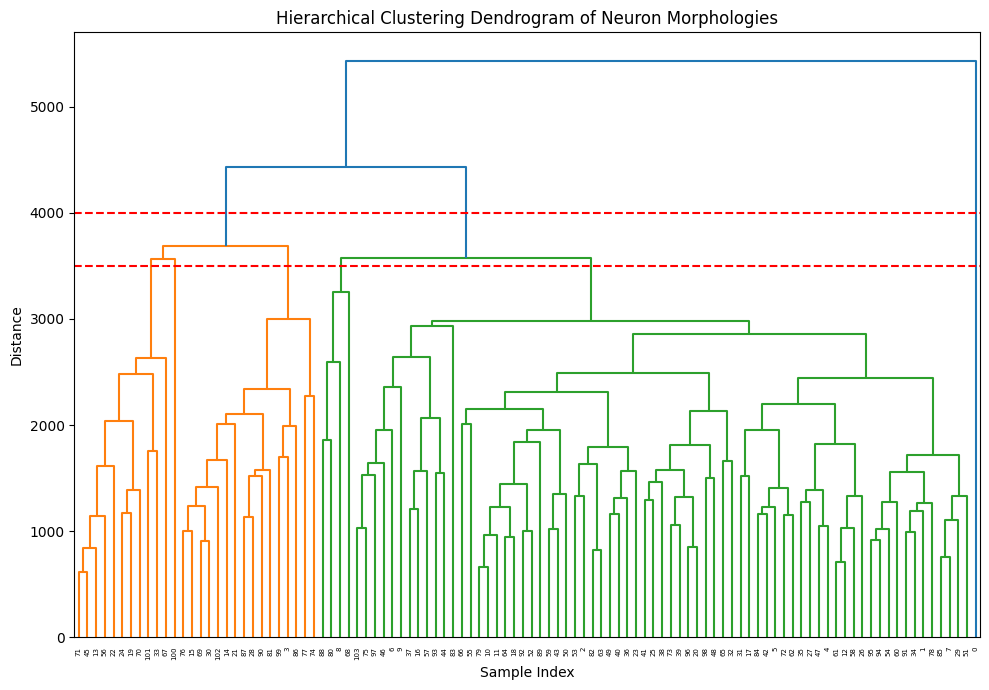

In [141]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# Convert the full distance matrix to a condensed form
# Take only the upper triangular part of the matrix
d = squareform(distance_matrix_np)
linked = linkage(d, 'complete')

# The rest of the code remains as is
# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, 
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram of Neuron Morphologies')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()

# save cluster labels from linkage with distance threshold
from scipy.cluster.hierarchy import fcluster
threshold = 4000  # Set your desired threshold
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
soma_df["cluster"] = fcluster(linked, threshold, criterion='distance')
threshold = 3500  # Set your desired threshold
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
soma_df["cluster2"] = fcluster(linked, threshold, criterion='distance')


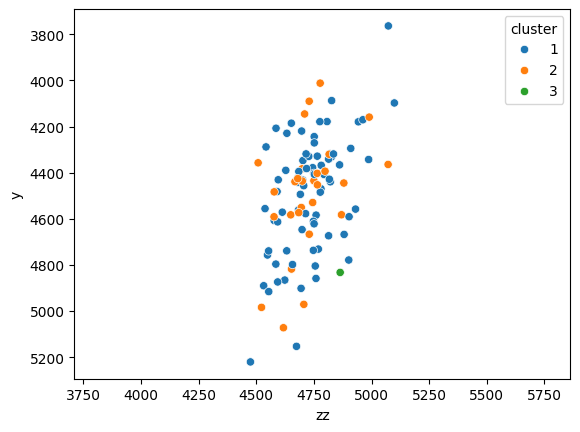

In [135]:
sns.scatterplot(soma_df, x="zz", y="y", hue="cluster", palette="tab10", legend=True)
plt.axis('equal')
plt.gca().invert_yaxis()

## unnormalized MDS

In [126]:
def format_plot():
    plt.axis('equal')
    plt.box(False)
    plt.xticks([])
    plt.yticks([])

In [124]:
from sklearn import manifold
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

model = manifold.MDS(n_components=2, dissimilarity="precomputed", random_state=42)

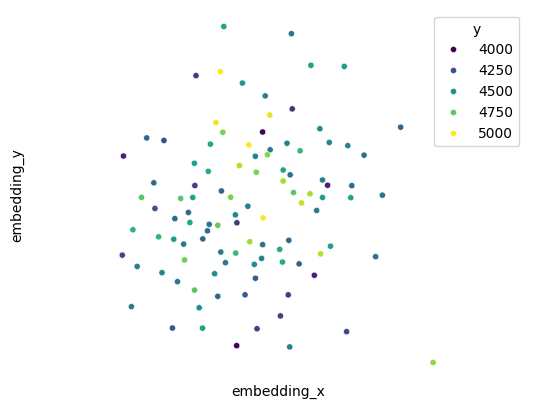

In [128]:
# soma_df_good = merged.dropna(subset=["r2"])
# good = merged["r2"].notna().values.nonzero()[0]
# # index np array with two 1D lists...
# embedding = model.fit_transform(distance_matrix_np[np.ix_(good, good)])

embedding = model.fit_transform(distance_matrix_np)
soma_df[["embedding_x", "embedding_y"]] = embedding

sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
format_plot()

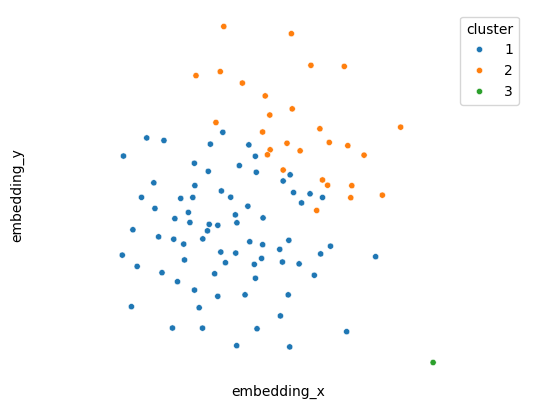

In [129]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster", palette="tab10", s=20, hue_norm=(4000, 5000))
format_plot()

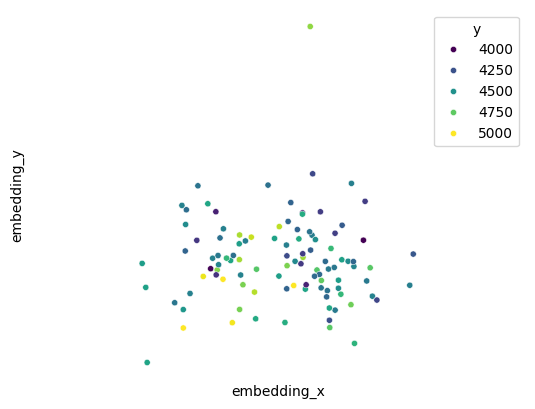

In [138]:
n_components=100
model = manifold.MDS(n_components=n_components, dissimilarity="precomputed", random_state=42)

embedding_highd = model.fit_transform(distance_matrix_np)
embedding = PCA(n_components=2).fit_transform(embedding_highd)
soma_df[["embedding_x", "embedding_y"]] = embedding

sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
format_plot()


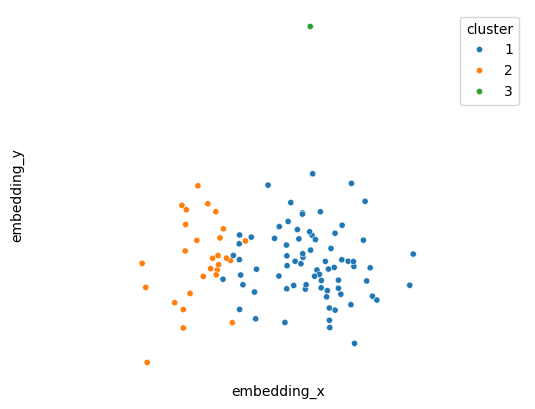

In [139]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster", palette="tab10", s=20, hue_norm=(4000, 5000))
format_plot()

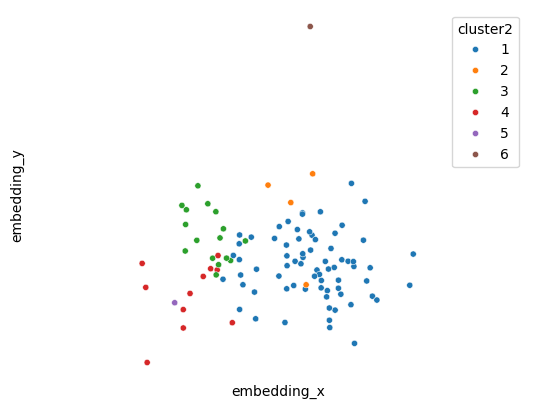

In [142]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster2", palette="tab10", s=20, hue_norm=(4000, 5000))
format_plot()

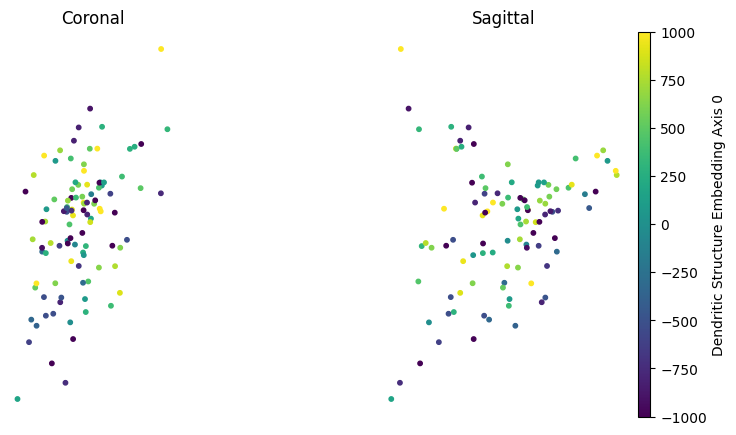

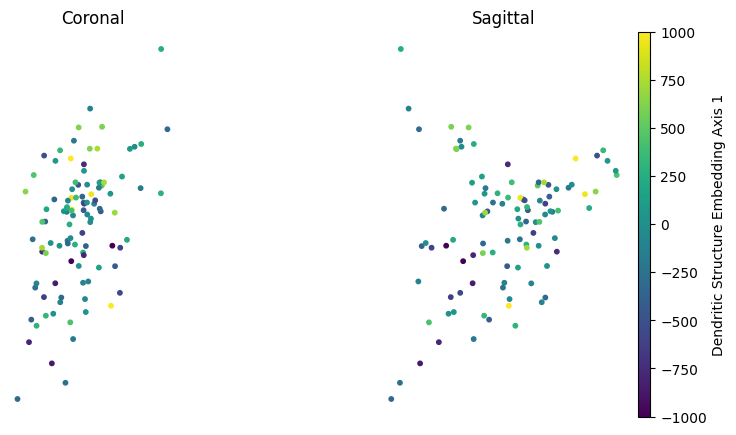

In [88]:
u.two_view_plot(soma_df, embedding, 0, s=10)
u.two_view_plot(soma_df, embedding, 1, s=10)


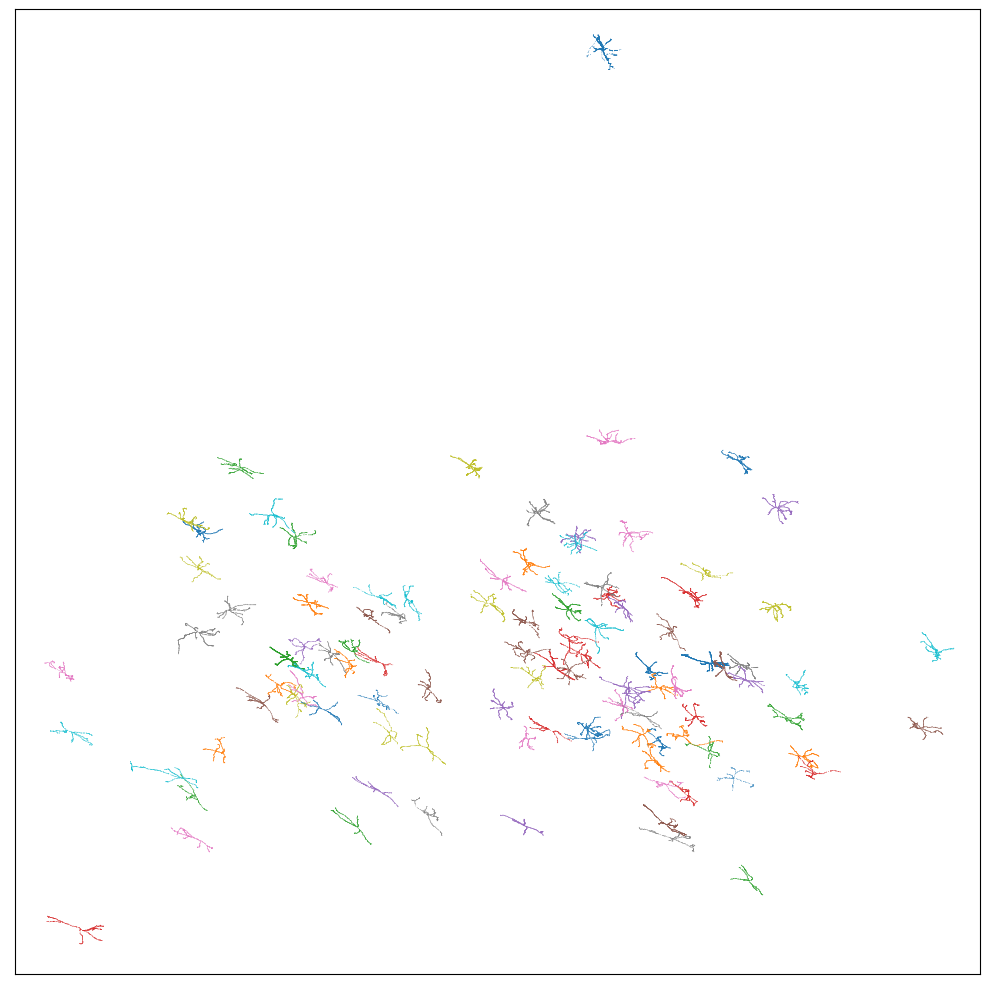

In [89]:
fig = u.create_morphology_scatter_plot(embedding, morphos, files, coords='xy')
# ax.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"], zorder=100)

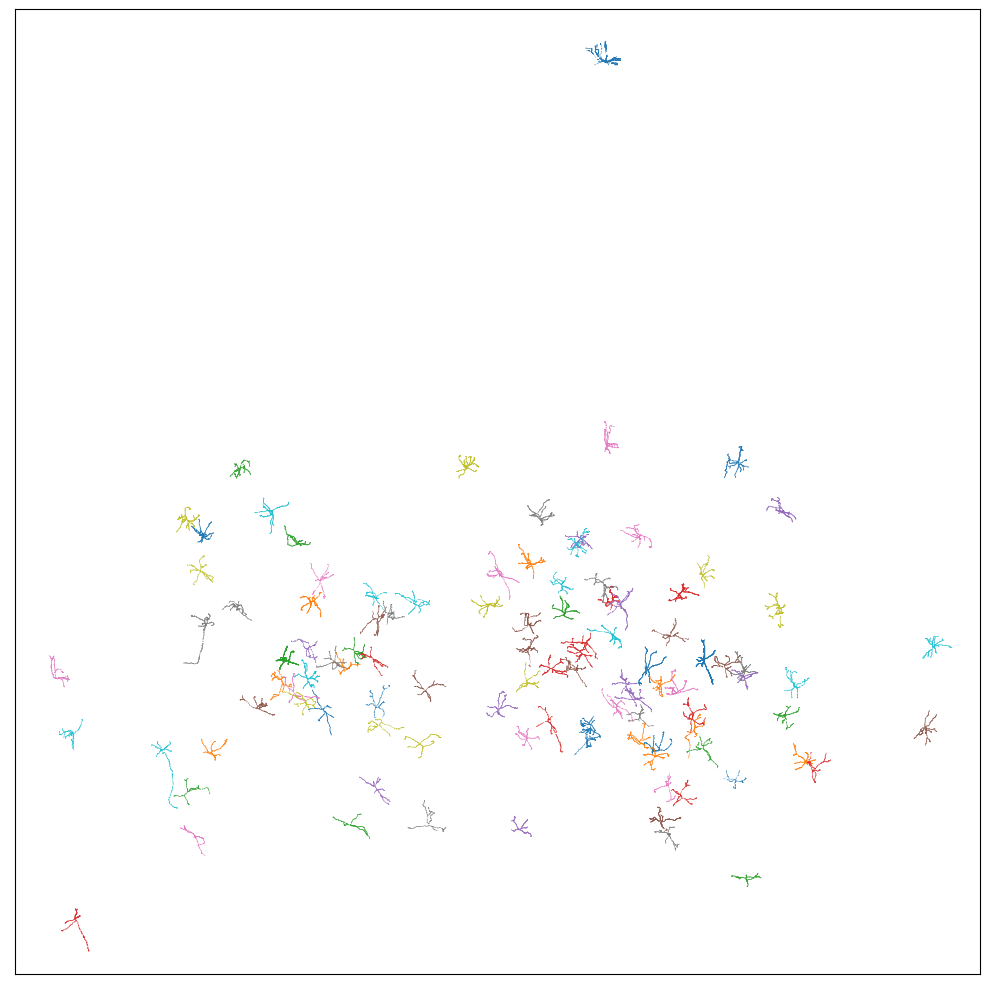

In [90]:
fig = create_morphology_scatter_plot(embedding, morphos, files, coords='yz')

## normalized MDS

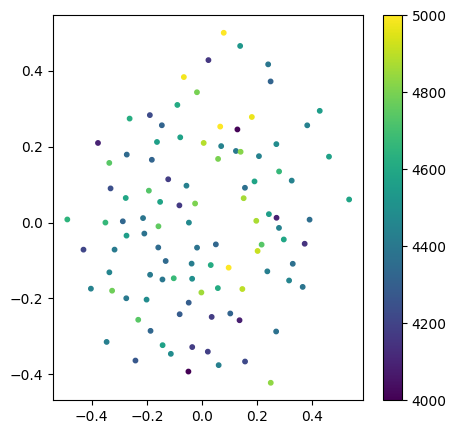

In [101]:
embedding = model.fit_transform(norm_distance_matrix_np)

plt.figure(figsize=(5, 5))
plt.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"])
clim=(4000, 5000)
plt.clim(clim)
plt.colorbar()

In [93]:
n_components=100
model = manifold.MDS(n_components=n_components, dissimilarity="precomputed", random_state=42)

embedding_highd = model.fit_transform(norm_distance_matrix_np)
embedding = PCA(n_components=2).fit_transform(embedding_highd)


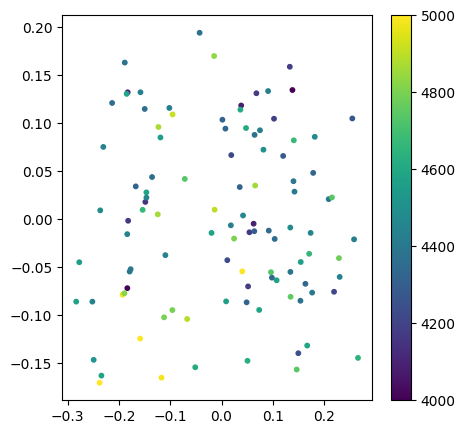

In [94]:
# DV position
plt.figure(figsize=(5, 5))
plt.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"])
clim=(4000, 5000)
plt.clim(clim)
plt.colorbar()

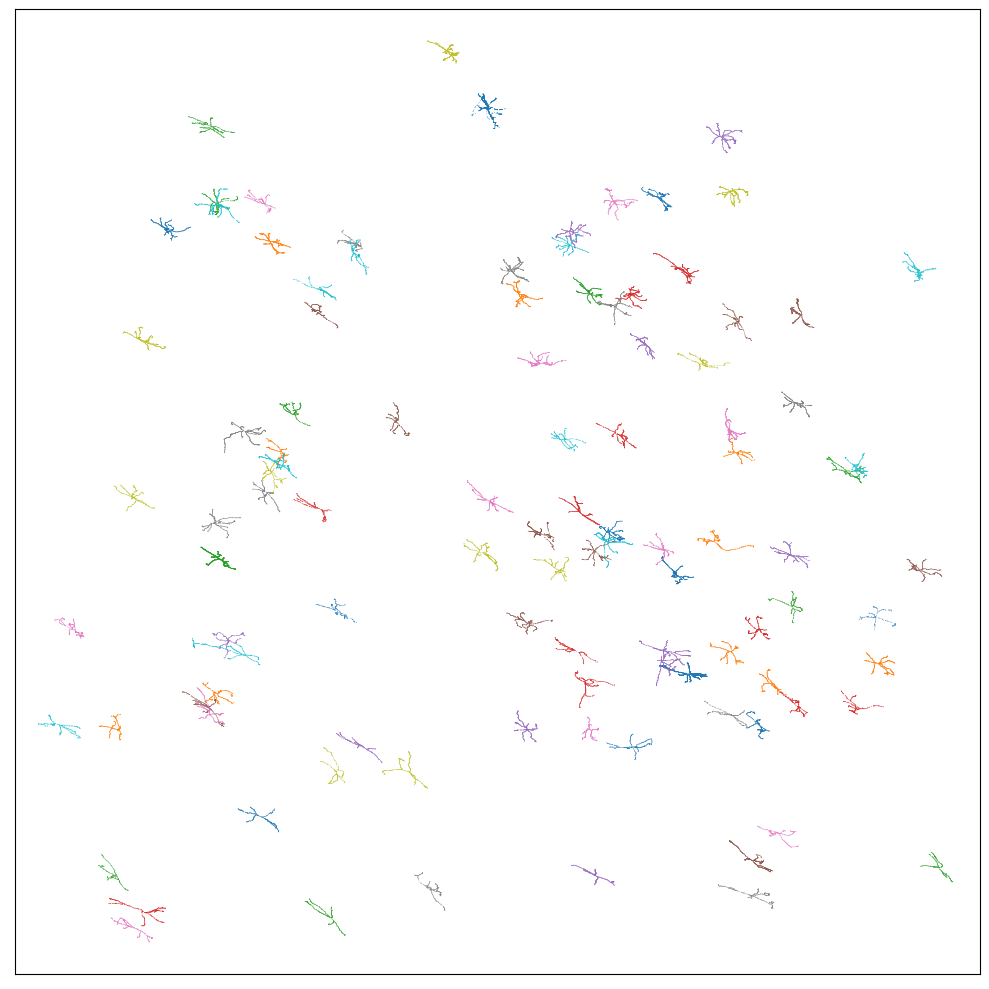

In [95]:
fig = u.create_morphology_scatter_plot(embedding, morphos, files, coords='xy')
# ax.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"], zorder=100)

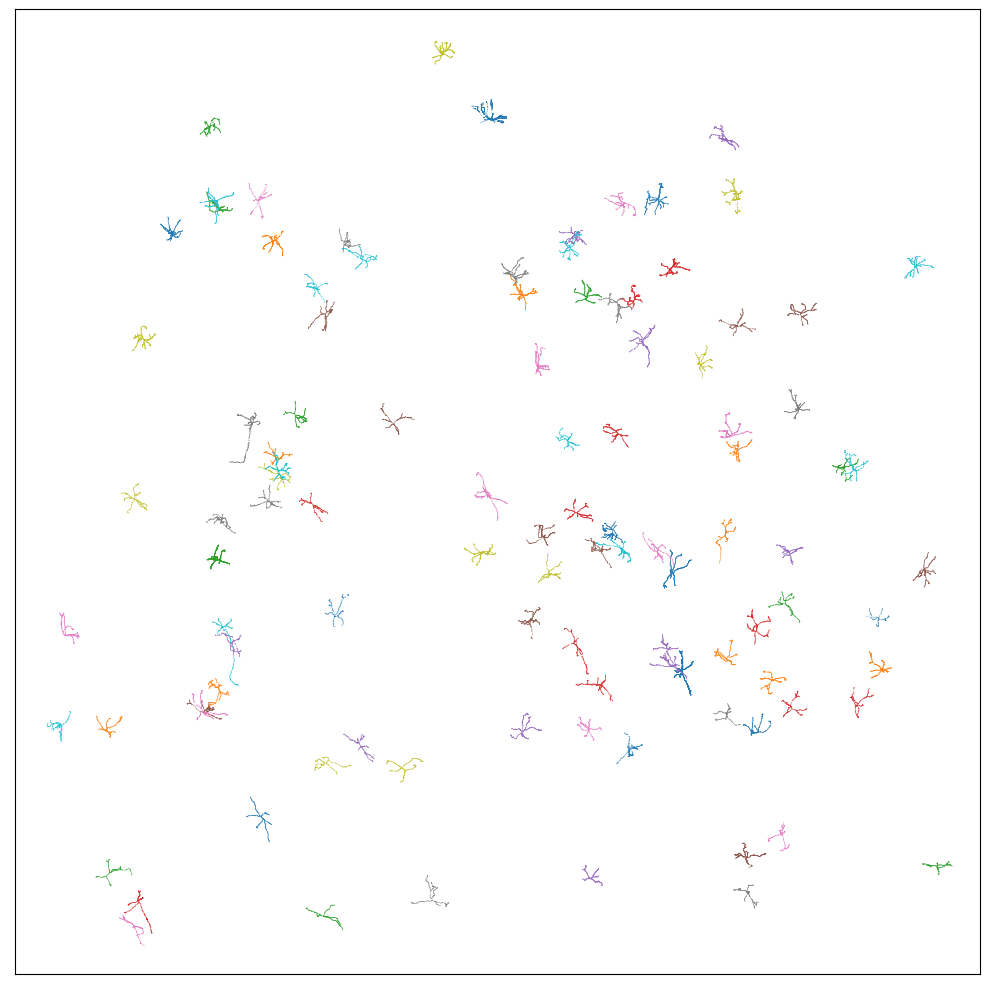

In [96]:
fig = u.create_morphology_scatter_plot(embedding, morphos, files, coords='yz')
# ax.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"], zorder=100)

## unnormalized TSNE

([], [])

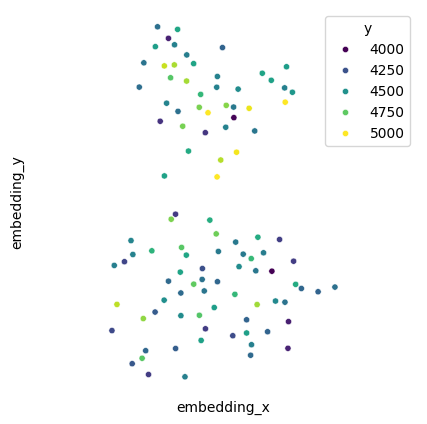

In [119]:
model = manifold.TSNE(n_components=2, metric="precomputed", init="random", random_state=42, perplexity=10)
embedding = model.fit_transform(distance_matrix_np)
soma_df[["embedding_x", "embedding_y"]] = embedding

plt.figure(figsize=(5, 5))
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
format_plot()


([], [])

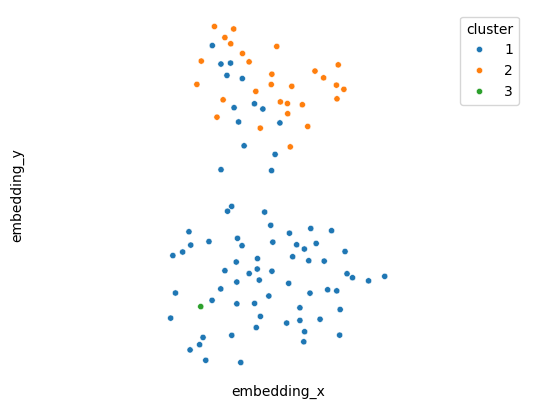

In [123]:

sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster", palette="tab10", s=20, hue_norm=(4000, 5000))
format_plot()

## unnormalized UMAP

/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/conda/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


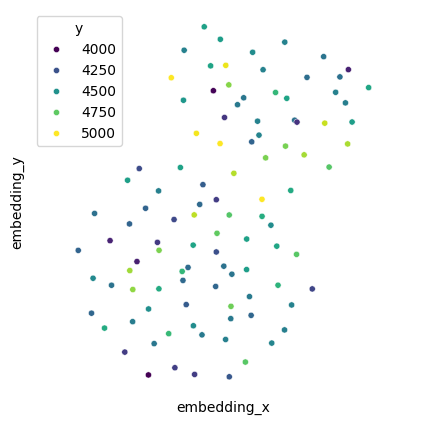

In [136]:
from umap import UMAP
model = UMAP(n_components=2, metric="precomputed", random_state=42, min_dist=1)
embedding = model.fit_transform(distance_matrix_np)
soma_df[["embedding_x", "embedding_y"]] = embedding

plt.figure(figsize=(5, 5))
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
format_plot()

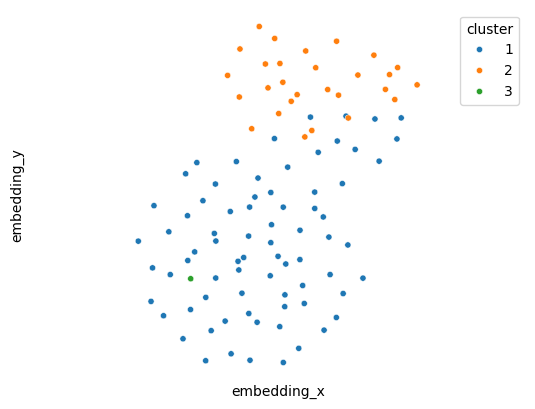

In [137]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster", palette="tab10", s=20, hue_norm=(4000, 5000))
format_plot()

# Convex

## distances

In [ ]:

func = lambda x: u.compare(x, "convex")
print(f"Number of pairs: {len(pairs)}")
generator = Parallel(n_jobs=16, return_as="generator", verbose=10)(delayed(func)(pair) for pair in pairs)
# results = list(tqdm(generator, desc="Comparing trees", unit="pair", total=len(pairs)))
results = list(generator)



Number of pairs: 5778


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


Error comparing /data/648434_12_5_24/Complete_annotated/N022-648434-PG.json and /data/648434_12_5_24/Complete_annotated/N024-648434-SS.json: 'dendrite'


 71%|███████▏  | 20/28 [00:06<00:03,  2.47it/s]

Error comparing /data/648434_12_5_24/Complete_annotated/N022-648434-PG.json and /data/685221_12_5_24/Complete_annotated/N025-685221-PG.json: 'dendrite'


...

 95%|█████████▍| 73/77 [02:31<00:05,  1.30s/it]

Error comparing /data/685221_12_5_24/Complete_annotated/N025-685221-PG.json and /data/685222_2_17_25_unrefined/Complete_annotated/N001-685222-SA.json: 'dendrite'


 96%|█████████▌| 74/77 [02:53<00:05,  1.71s/it]

Error comparing /data/685221_12_5_24/Complete_annotated/N025-685221-PG.json and /data/685222_2_17_25_unrefined/Complete_annotated/N012-685222-BP.json: 'dendrite'


 96%|█████████▌| 74/77 [02:33<00:04,  1.48s/it]

In [ ]:
import pandas as pd
df = pd.DataFrame.from_records(results).dropna(how="any")
# files = pd.concat([df["file1"], df["file2"]]).unique()
# files.sort()
df.head()

,file1,file2,distance,norm_distance
0,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N023-6...,3913.1817,0.5668
2,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N020-6...,4078.5686,0.5691
3,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N011-6...,3765.9351,0.5263
4,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N025-6...,4370.9496,0.6329
5,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N004-6...,3589.0133,0.5107


In [ ]:

files = soma_df["file"]
file_dict = {f: i for i, f in enumerate(files)}
n_files = len(files)
distance_matrix_np = np.zeros((n_files, n_files))
norm_distance_matrix_np = np.zeros((n_files, n_files))

for i, row in df.iterrows():
    file1 = row["file1"]
    file2 = row["file2"]
    distance = row["distance"]
    norm_distance = row["norm_distance"]
    distance_matrix_np[file_dict[file1], file_dict[file2]] = distance
    distance_matrix_np[file_dict[file2], file_dict[file1]] = distance
    norm_distance_matrix_np[file_dict[file1], file_dict[file2]] = norm_distance
    norm_distance_matrix_np[file_dict[file2], file_dict[file1]] = norm_distance
    

In [ ]:
f"Number of positive eigenvalues: {np.sum(eigvals > 1e-10)} out of {len(eigvals)}"

'Number of positive eigenvalues: 95 out of 95'

## clustering

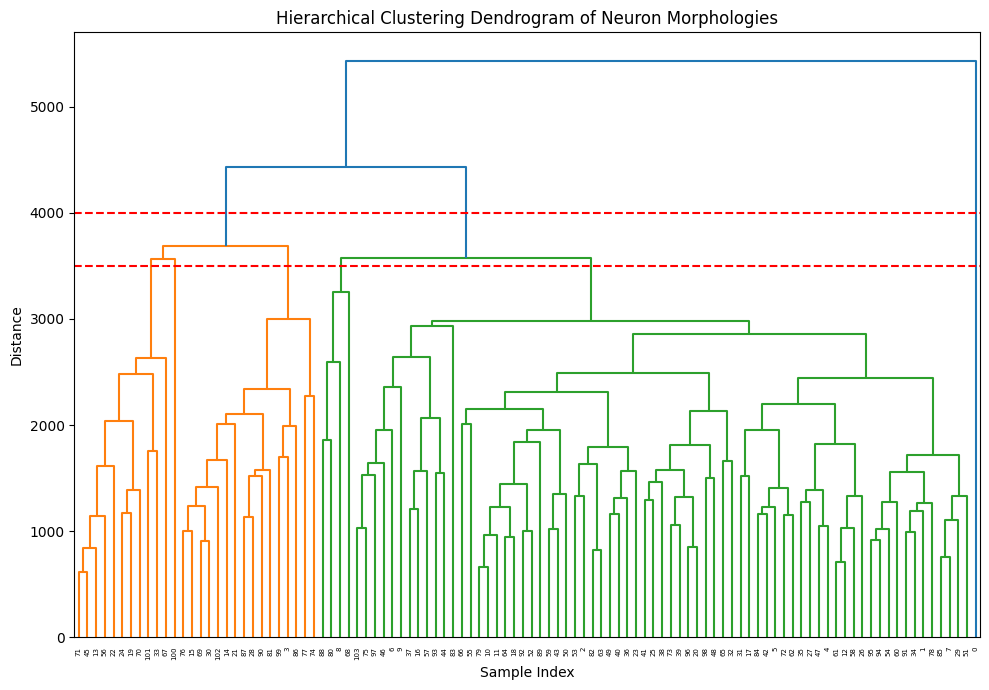

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# Convert the full distance matrix to a condensed form
# Take only the upper triangular part of the matrix
d = squareform(distance_matrix_np)
linked = linkage(d, 'complete')

# The rest of the code remains as is
# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, 
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram of Neuron Morphologies')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()

# save cluster labels from linkage with distance threshold
from scipy.cluster.hierarchy import fcluster
threshold = 4000  # Set your desired threshold
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
soma_df["cluster"] = fcluster(linked, threshold, criterion='distance')
threshold = 3500  # Set your desired threshold
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
soma_df["cluster2"] = fcluster(linked, threshold, criterion='distance')


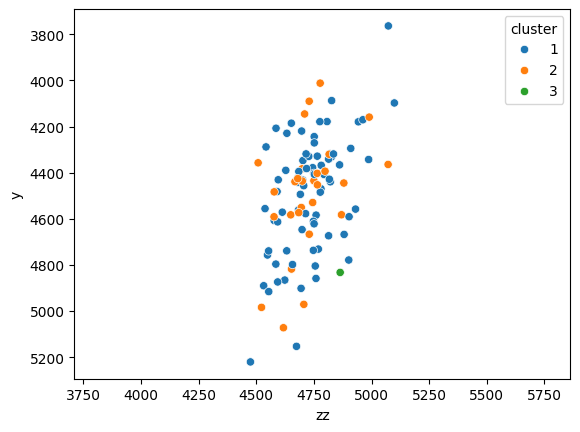

In [ ]:
sns.scatterplot(soma_df, x="zz", y="y", hue="cluster", palette="tab10", legend=True)
plt.axis('equal')
plt.gca().invert_yaxis()

## unnormalized MDS

In [ ]:
def format_plot():
    plt.axis('equal')
    plt.box(False)
    plt.xticks([])
    plt.yticks([])

In [ ]:
from sklearn import manifold
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

model = manifold.MDS(n_components=2, dissimilarity="precomputed", random_state=42)

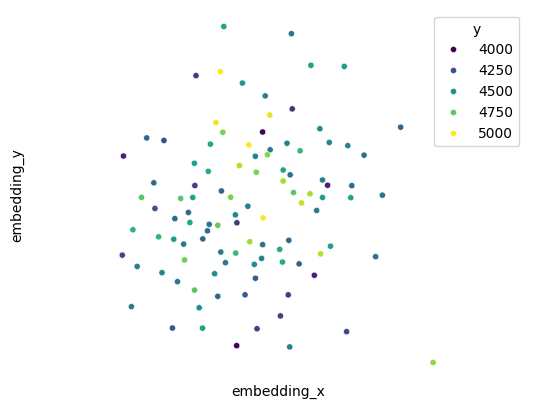

In [ ]:
# soma_df_good = merged.dropna(subset=["r2"])
# good = merged["r2"].notna().values.nonzero()[0]
# # index np array with two 1D lists...
# embedding = model.fit_transform(distance_matrix_np[np.ix_(good, good)])

embedding = model.fit_transform(distance_matrix_np)
soma_df[["embedding_x", "embedding_y"]] = embedding

sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
format_plot()

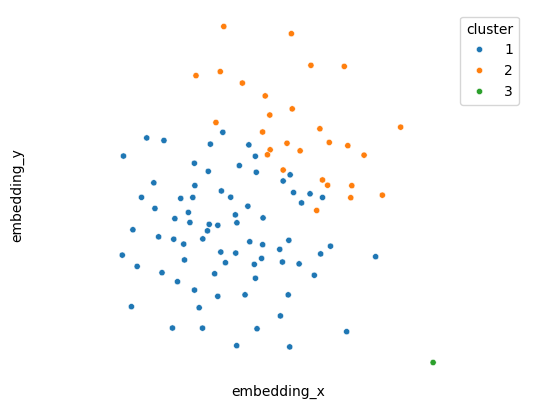

In [ ]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster", palette="tab10", s=20, hue_norm=(4000, 5000))
format_plot()

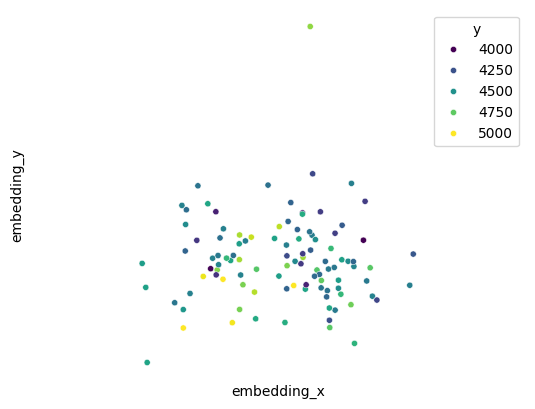

In [ ]:
n_components=100
model = manifold.MDS(n_components=n_components, dissimilarity="precomputed", random_state=42)

embedding_highd = model.fit_transform(distance_matrix_np)
embedding = PCA(n_components=2).fit_transform(embedding_highd)
soma_df[["embedding_x", "embedding_y"]] = embedding

sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
format_plot()


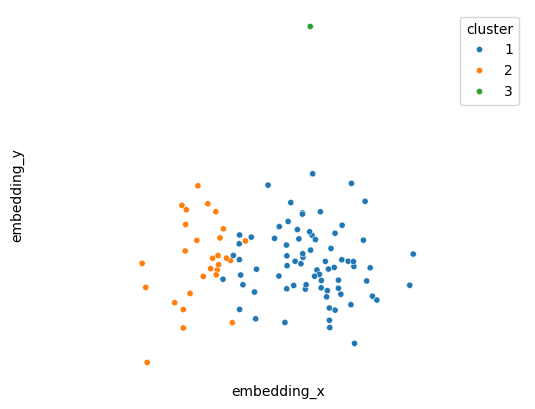

In [ ]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster", palette="tab10", s=20, hue_norm=(4000, 5000))
format_plot()

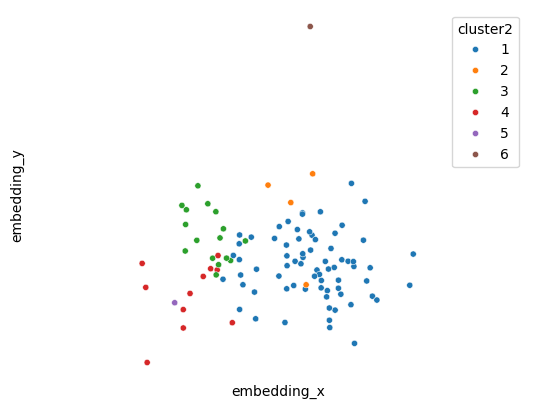

In [ ]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster2", palette="tab10", s=20, hue_norm=(4000, 5000))
format_plot()

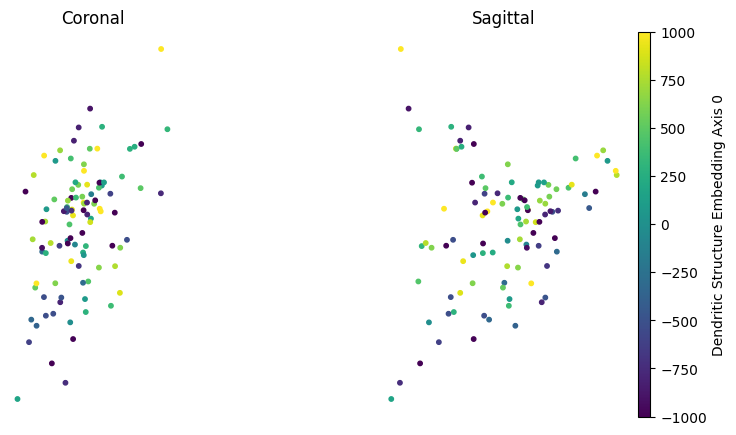

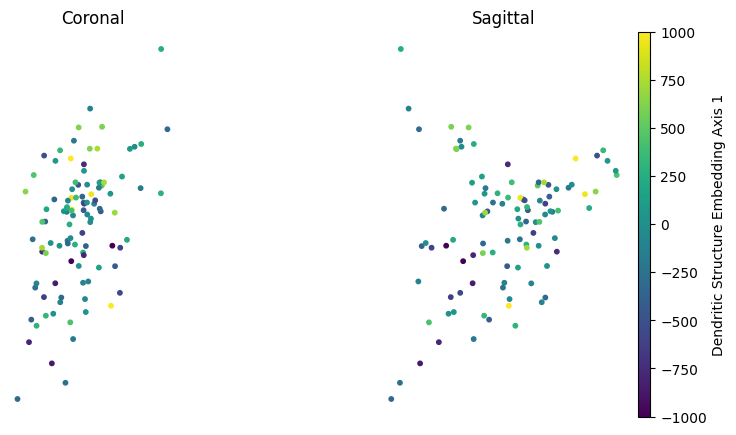

In [ ]:
u.two_view_plot(soma_df, embedding, 0, s=10)
u.two_view_plot(soma_df, embedding, 1, s=10)


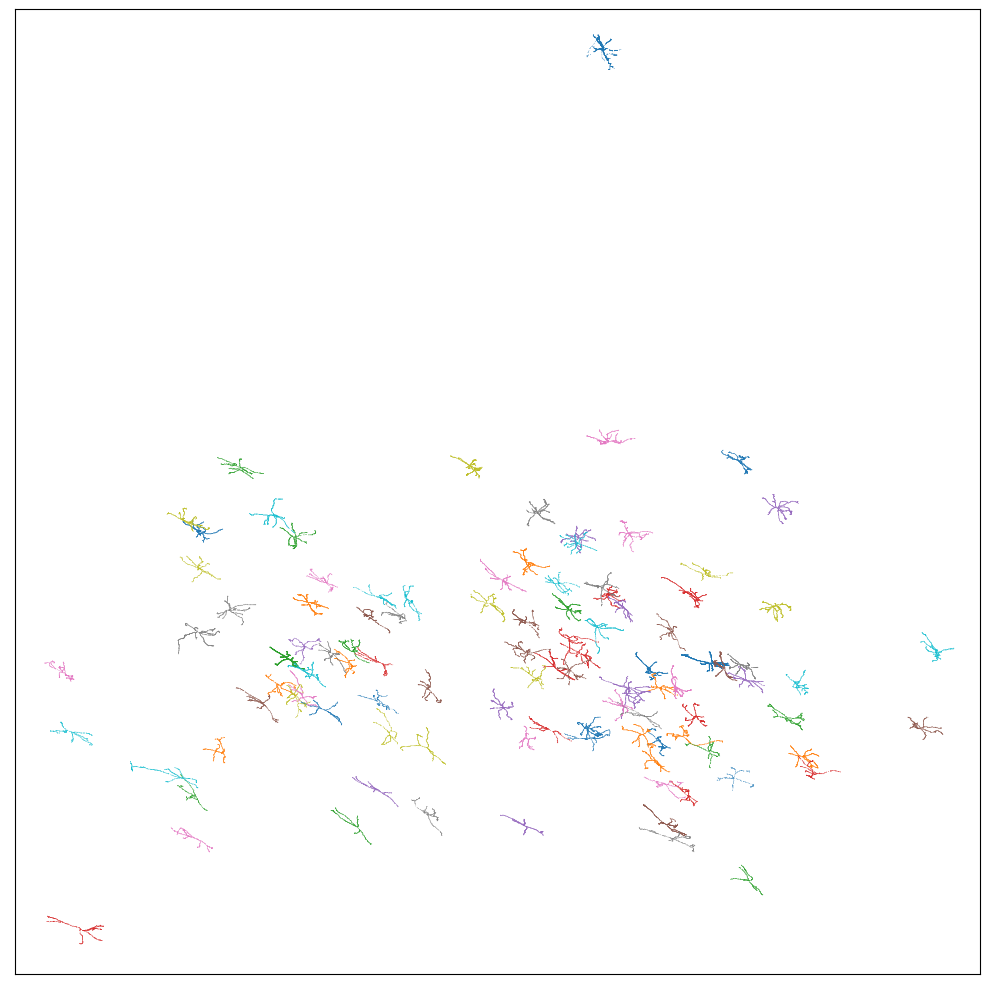

In [ ]:
fig = u.create_morphology_scatter_plot(embedding, morphos, files, coords='xy')
# ax.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"], zorder=100)

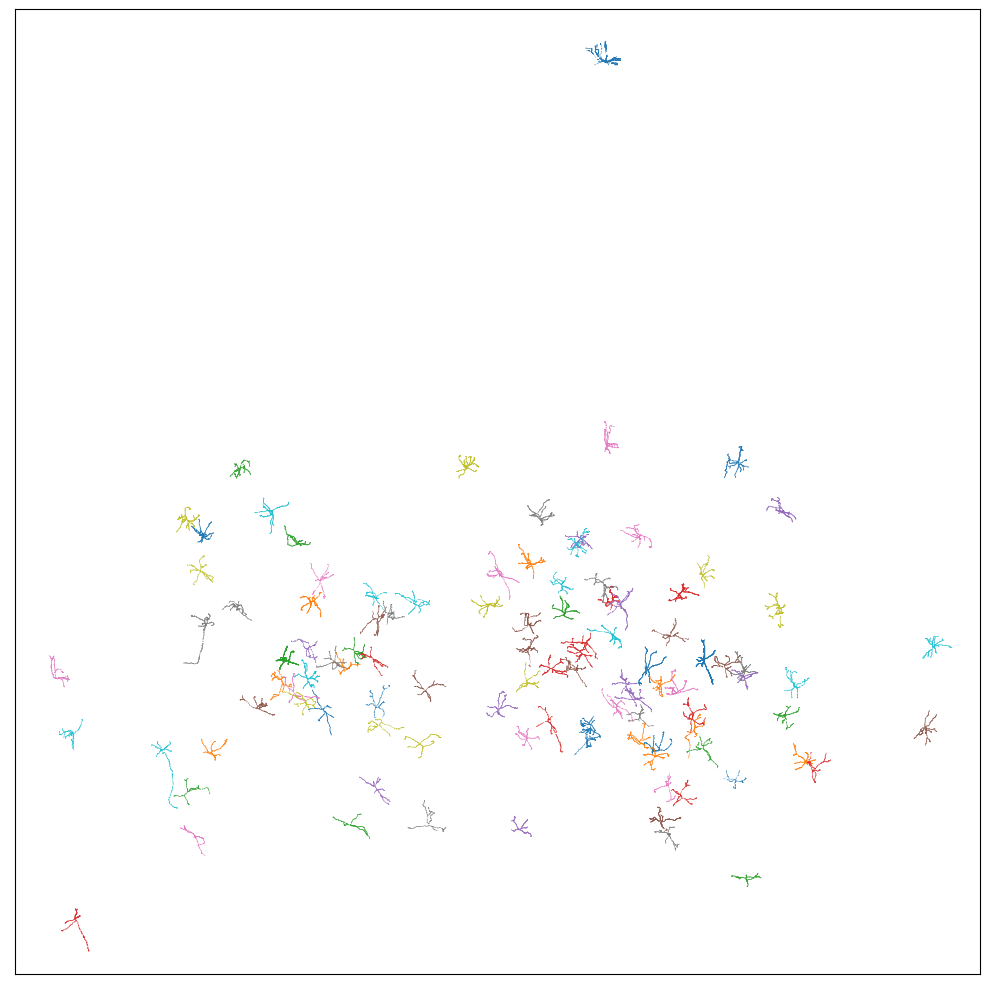

In [ ]:
fig = create_morphology_scatter_plot(embedding, morphos, files, coords='yz')

## normalized MDS

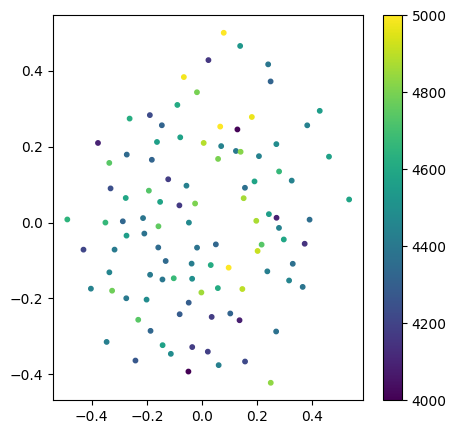

In [ ]:
embedding = model.fit_transform(norm_distance_matrix_np)

plt.figure(figsize=(5, 5))
plt.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"])
clim=(4000, 5000)
plt.clim(clim)
plt.colorbar()

In [ ]:
n_components=100
model = manifold.MDS(n_components=n_components, dissimilarity="precomputed", random_state=42)

embedding_highd = model.fit_transform(norm_distance_matrix_np)
embedding = PCA(n_components=2).fit_transform(embedding_highd)


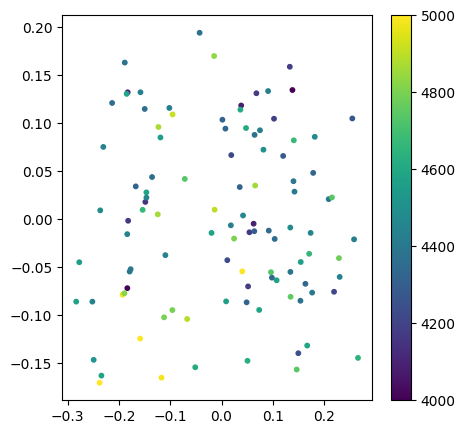

In [ ]:
# DV position
plt.figure(figsize=(5, 5))
plt.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"])
clim=(4000, 5000)
plt.clim(clim)
plt.colorbar()

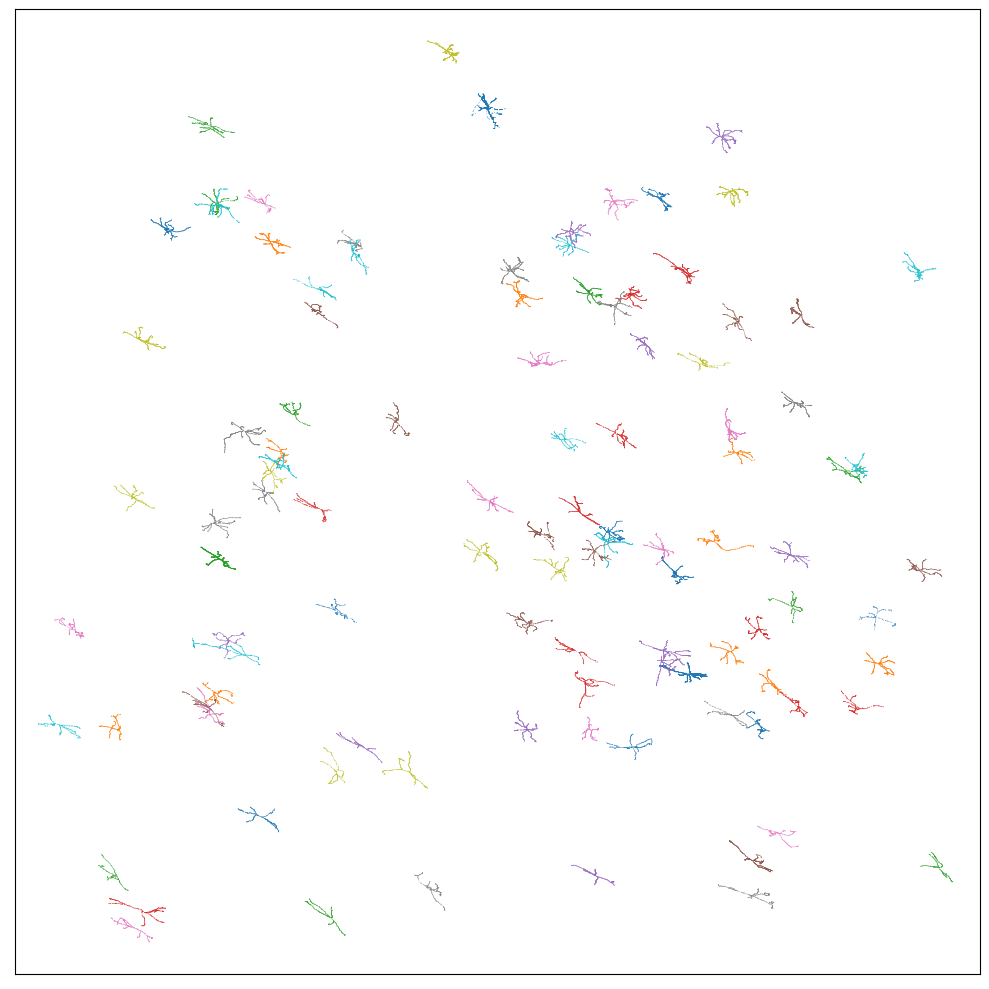

In [ ]:
fig = u.create_morphology_scatter_plot(embedding, morphos, files, coords='xy')
# ax.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"], zorder=100)

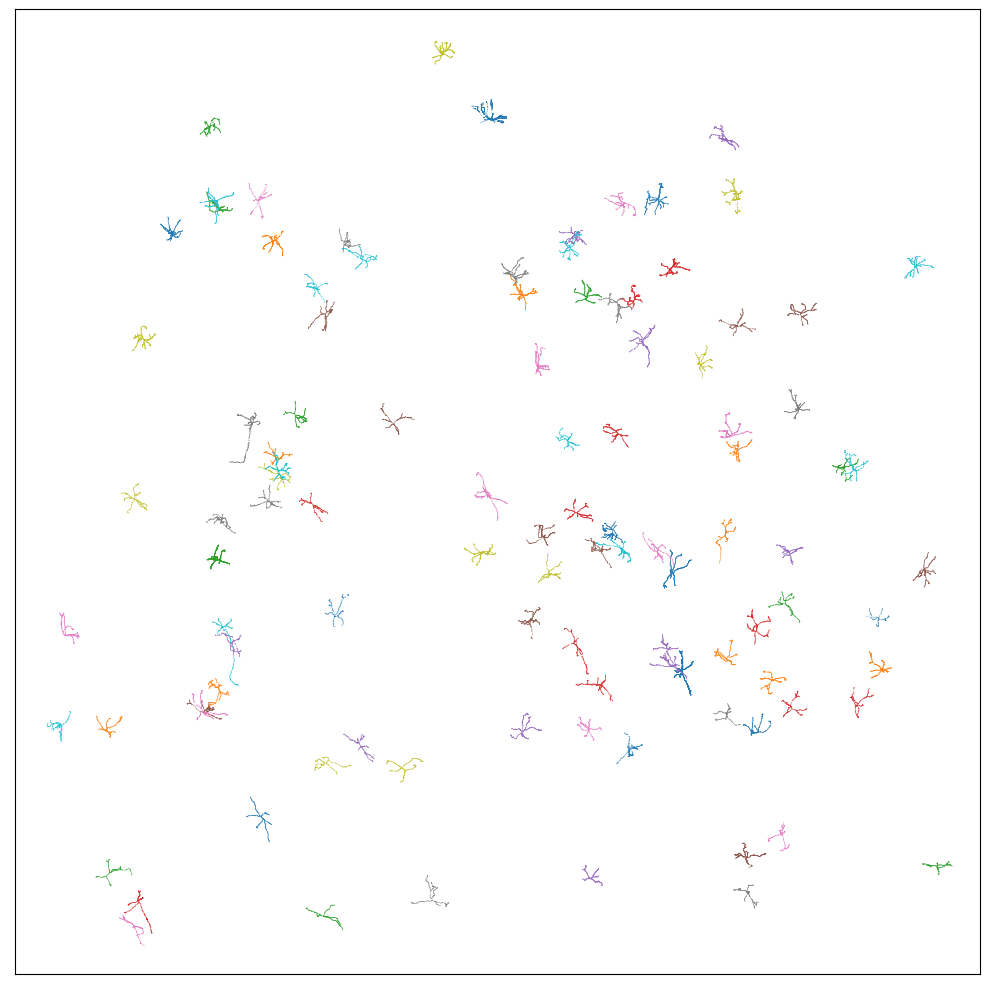

In [ ]:
fig = u.create_morphology_scatter_plot(embedding, morphos, files, coords='yz')
# ax.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"], zorder=100)

## unnormalized TSNE

([], [])

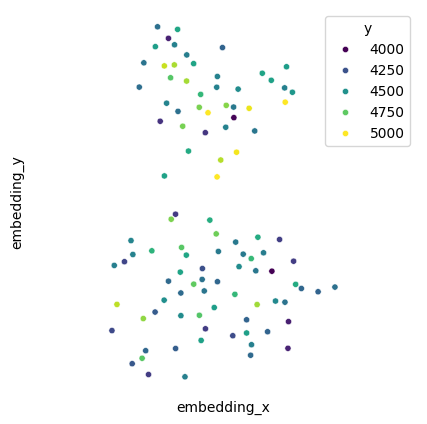

In [ ]:
model = manifold.TSNE(n_components=2, metric="precomputed", init="random", random_state=42, perplexity=10)
embedding = model.fit_transform(distance_matrix_np)
soma_df[["embedding_x", "embedding_y"]] = embedding

plt.figure(figsize=(5, 5))
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
format_plot()


([], [])

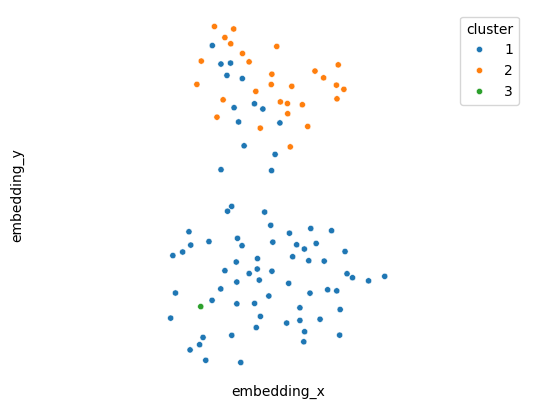

In [ ]:

sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster", palette="tab10", s=20, hue_norm=(4000, 5000))
format_plot()

## unnormalized UMAP

/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/conda/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


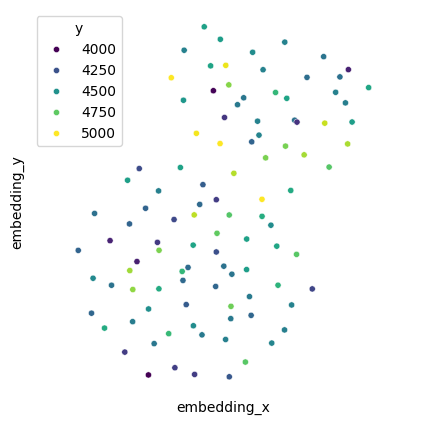

In [ ]:
from umap import UMAP
model = UMAP(n_components=2, metric="precomputed", random_state=42, min_dist=1)
embedding = model.fit_transform(distance_matrix_np)
soma_df[["embedding_x", "embedding_y"]] = embedding

plt.figure(figsize=(5, 5))
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
format_plot()

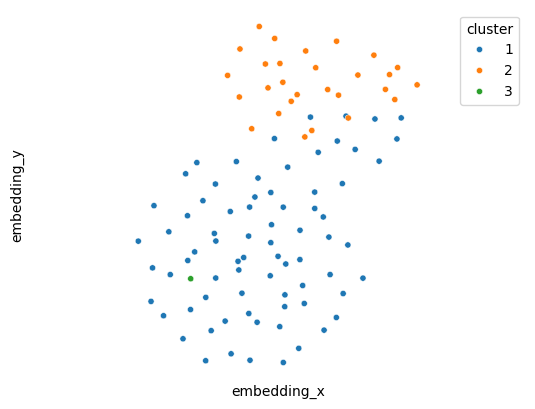

In [ ]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster", palette="tab10", s=20, hue_norm=(4000, 5000))
format_plot()

# LC mesh comparisons

 Dendrites relationship to edges
 - direction correlation with surface normalize?
 - magnitude of dendrite CoM anticorrelated with distance to surface?

In [ ]:
# install trimesh, rtree

In [ ]:
import trimesh

# Load mesh
mesh = trimesh.load('/root/capsule/data/lc_meshes/20250418_transformed_remesh_10.obj')

2025-05-16 17:31:52,394 trimesh      INFO     triangulating faces


In [ ]:

soma_df["z"] = np.minimum(soma_df["z"], 11400-soma_df["z"])
soma_df[["x", "y", "z"]].mean()
soma_center = soma_df[["x", "y", "z"]].mean().values
mesh_center = mesh.bounding_box.centroid
soma_center - mesh_center

array([105.99100354,  68.8277215 , -51.85861085])

In [ ]:
# offset gives 80 vs 73 (out of 104) cells inside

# mesh.vertices = mesh.vertices + soma_center - mesh_center

In [ ]:

# Query point
point = mesh_center

# Find closest point on mesh
closest_point, distance, triangle_id = trimesh.proximity.closest_point(mesh, [point])

print(f"Closest point: {closest_point[0]}")
print(f"Distance: {distance[0]}")

Closest point: [10452.62358245  4484.96890442  4895.85679036]
Distance: 129.19887102181175


In [ ]:
records = []
for _, row in soma_df.iterrows():
    point = row[["x", "y", "z"]].values 
    # check if point is inside the mesh
    inside = mesh.contains([point])
    if not inside[0]:
        continue
    closest_point, distance, triangle_id = trimesh.proximity.closest_point(mesh, [point])
    ds = point - closest_point[0]
    scaled_sep = ds / np.linalg.norm(ds)
    morpho = morphos[row["file"]]

    # is sampling uniform??
    dend_sep = (
        pd.DataFrame.from_records(morpho.get_node_by_types([BASAL_DENDRITE]))[["x", "y", "z"]].mean() -
        pd.DataFrame.from_records(morpho.get_node_by_types([SOMA]))[["x", "y", "z"]].mean()
    )
    dend_dist = np.linalg.norm(dend_sep)
    dend_sep = dend_sep / dend_dist
    records.append({
        "file": row["file"],
        "distance": distance[0],
        "dend_distance": dend_dist,
        "scaled_sep": scaled_sep,
        "dend_sep": dend_sep,
        "scaled_sep_x": scaled_sep[0],
        "scaled_sep_y": scaled_sep[1],
        "scaled_sep_z": scaled_sep[2],
        "dend_sep_x": dend_sep[0],
        "dend_sep_y": dend_sep[1],
        "dend_sep_z": dend_sep[2],
    })
df = pd.DataFrame.from_records(records)



In [ ]:
f"{len(df)} cells within boundaries, {len(soma_df)} cells total"

'73 cells within boundaries, 104 cells total'

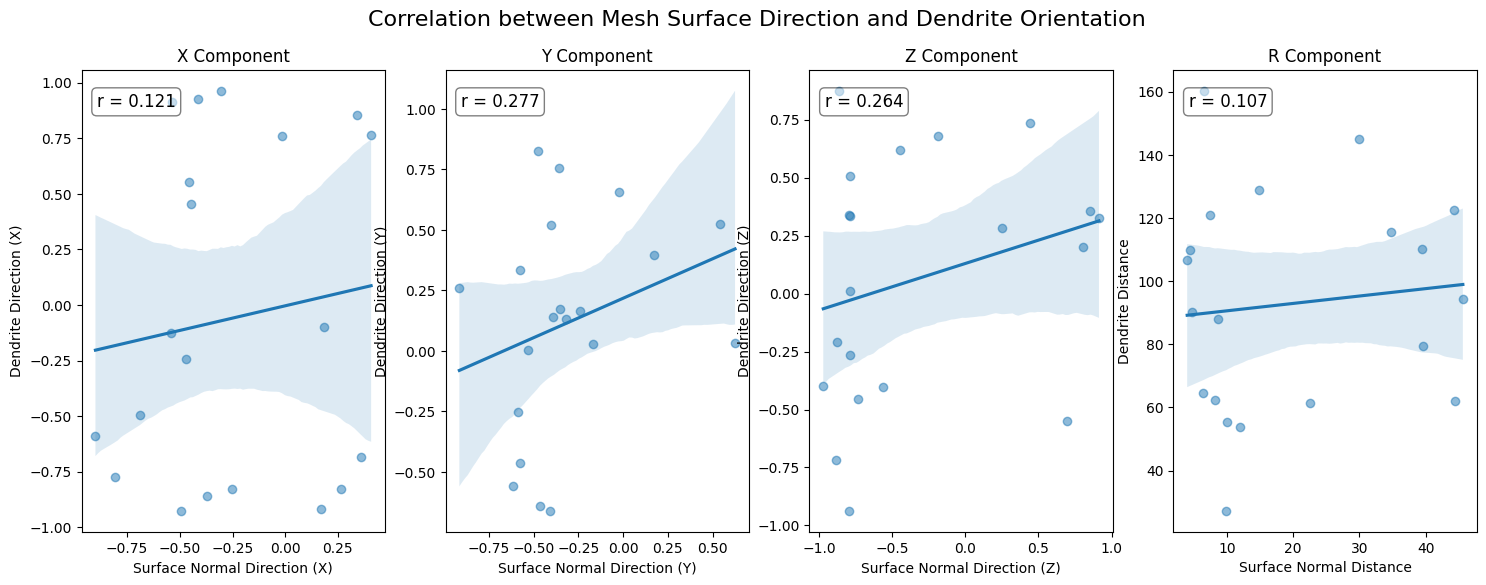

In [ ]:
# Create a figure with 4 subplots for the x, y, and z components along with distance

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
records = df
records = records[records['distance'] < 50]
# Add title to the overall figure
fig.suptitle("Correlation between Mesh Surface Direction and Dendrite Orientation", fontsize=16)

# Plot x component
sns.regplot(x="scaled_sep_x", y="dend_sep_x", data=records, ax=axes[0], scatter_kws={'alpha': 0.5})
axes[0].set_title("X Component")
axes[0].set_xlabel("Surface Normal Direction (X)")
axes[0].set_ylabel("Dendrite Direction (X)")
r_x = np.corrcoef(records['scaled_sep_x'], records['dend_sep_x'])[0, 1]
axes[0].text(0.05, 0.95, f"r = {r_x:.3f}", transform=axes[0].transAxes, fontsize=12, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# Plot y component
sns.regplot(x="scaled_sep_y", y="dend_sep_y", data=records, ax=axes[1], scatter_kws={'alpha': 0.5})
axes[1].set_title("Y Component")
axes[1].set_xlabel("Surface Normal Direction (Y)")
axes[1].set_ylabel("Dendrite Direction (Y)")
r_y = np.corrcoef(records['scaled_sep_y'], records['dend_sep_y'])[0, 1]
axes[1].text(0.05, 0.95, f"r = {r_y:.3f}", transform=axes[1].transAxes, fontsize=12, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# Plot z component
sns.regplot(x="scaled_sep_z", y="dend_sep_z", data=records, ax=axes[2], scatter_kws={'alpha': 0.5})
axes[2].set_title("Z Component")
axes[2].set_xlabel("Surface Normal Direction (Z)")
axes[2].set_ylabel("Dendrite Direction (Z)")
r_z = np.corrcoef(records['scaled_sep_z'], records['dend_sep_z'])[0, 1]
axes[2].text(0.05, 0.95, f"r = {r_z:.3f}", transform=axes[2].transAxes, fontsize=12, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

fig = create_morphology_scatter_plot(embedding, morphos, files, coords='xy')
# Plot z component
sns.regplot(x="distance", y="dend_distance", data=records, ax=axes[3], scatter_kws={'alpha': 0.5})
axes[3].set_title("R Component")
axes[3].set_xlabel("Surface Normal Distance")
axes[3].set_ylabel("Dendrite Distance")
r_z = np.corrcoef(records['distance'], records['dend_distance'])[0, 1]
axes[3].text(0.05, 0.95, f"r = {r_z:.3f}", transform=axes[3].transAxes, fontsize=12, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
# plt.tight_layout()
plt.subplots_adjust(top=0.88)

In [ ]:
import k3d

plot = k3d.plot()
plot += k3d.mesh(mesh.vertices, mesh.faces, opacity=0.5, color=0xFF0000)
plot += k3d.points(soma_df[["x", "y", "z"]].values, point_size=20, shader="3d", color=0x00FF00)
plot.display()

/opt/conda/lib/python3.9/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "float64" does not match required type "float32". A coerced copy has been created.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "int64" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "float64" does not match required type "float32". A coerced copy has been created.
  warnings.warn(


Output()